In [1]:
import numpy as np
import pandas as pd
import os
import jieba
from sklearn.feature_extraction.text import TfidfVectorizer


c:\Users\18820\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\jieba\_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 1.Convert to csv file

7.5

### Load stop words


In [2]:
def load_stopwords():
    stopwords = set()
    with open('../data/converted/cn_stopwords.txt', mode='r', encoding='utf-8') as stop:
        for line in stop:
            stopwords.add(line.strip())
        stop.close()
    return stopwords

stopwords = load_stopwords()

### Preprocessing

In [3]:
import re
def extract() -> list[dict]:
    # Check file structure and basic info of the dataset
    dataLink = '../data/THUCNews/THUCNews/'
    file_categories = os.listdir(dataLink)
    file_directories = []
    print(f'Categories: {file_categories}')
    for i in range(len(file_categories)):
        files_path = os.path.join(dataLink,file_categories[i]) # combine the directory, like 'data/THUCNews/THUCNews/体育, 娱乐, etc.'
        files = os.listdir(files_path)
        print(f'{file_categories[i]}: 共{len(files)}个文件{files[:5]}')
        file_directories.append(files_path)
    for i, directory in enumerate(file_directories):
        print(i, directory) # collect all directories of different categories
    
    # Traverse & Filter & Extract
    dataList = []
    regex = re.compile(r'^[\u4e00-\u9fa5]{2,4}$')   # extract Chinese characters with length within 2 and 4 only
    categories = ['Sports','Amusement','Furnishings','Lottery','Real Estate','Education']
    for j in range(len(file_directories)):
        text_length = []
        files = os.listdir(file_directories[j])
        if j in [0,1]:
            subset_len = int(len(files) * 0.75) #对于大类(体育 娱乐),取75%
        else:
            subset_len = len(files)  #其他类全取
        for k in files[:subset_len]:
            filename =os.path.join(file_directories[j],k)
            with open(filename, encoding="UTF-8", mode='r') as f:
                text = f.read()
                if(len(text) < 200): #只取长度大于200字的文本，避免后续TF-IDF产生太多空特征
                    f.close()
                    continue
                else:
                    text_length.append(len(text))
                    filtered = []
                    words = jieba.lcut(text, cut_all = False)
                    for l in words:
                        if l.strip() not in stopwords:   #remove blank
                            if regex.match(l):
                                filtered.append(l.strip())
                    dataList.append({'type': categories[j], #convert to English
                                        'filename': filename,
                                        'content': text,
                                        'segmented': ' '.join(filtered)})
                    f.close()
        print(f'{file_categories[j]} 类型下的文本,取{len(text_length)}篇,其中最长{max(text_length)}字,最短{min(text_length)}字,平均{sum(text_length) / len(text_length)}字;缺失数量{len([i for i in text_length if i == 0])}')
        subset_len = 10000
    return dataList
df = pd.DataFrame(extract())
df.iloc[::2000].to_csv('../data/converted/data.csv',encoding='utf-8-sig')
print(df.shape)
df.iloc[::8000]

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\18820\AppData\Local\Temp\jieba.cache


Categories: ['体育', '娱乐', '家居', '彩票', '房产', '教育']
体育: 共19948个文件['82044.txt', '82045.txt', '82046.txt', '82047.txt', '82048.txt']
娱乐: 共22416个文件['201820.txt', '201821.txt', '201822.txt', '201823.txt', '201824.txt']
家居: 共4690个文件['252132.txt', '252133.txt', '252134.txt', '252135.txt', '252136.txt']
彩票: 共1472个文件['262938.txt', '262939.txt', '262940.txt', '262941.txt', '262942.txt']
房产: 共4822个文件['279638.txt', '279639.txt', '279640.txt', '279641.txt', '279642.txt']
教育: 共1741个文件['290064.txt', '290065.txt', '290066.txt', '290067.txt', '290068.txt']
0 ../data/THUCNews/THUCNews/体育
1 ../data/THUCNews/THUCNews/娱乐
2 ../data/THUCNews/THUCNews/家居
3 ../data/THUCNews/THUCNews/彩票
4 ../data/THUCNews/THUCNews/房产
5 ../data/THUCNews/THUCNews/教育


Loading model cost 0.499 seconds.
Prefix dict has been built successfully.


体育 类型下的文本,取14582篇,其中最长10522字,最短200字,平均1037.306405157043字;缺失数量0
娱乐 类型下的文本,取16197篇,其中最长12778字,最短200字,平均1022.286719762919字;缺失数量0
家居 类型下的文本,取3989篇,其中最长26092字,最短201字,平均1125.8302832790173字;缺失数量0
彩票 类型下的文本,取1335篇,其中最长9046字,最短202字,平均1346.7280898876404字;缺失数量0
房产 类型下的文本,取4740篇,其中最长8485字,最短203字,平均805.5962025316455字;缺失数量0
教育 类型下的文本,取1585篇,其中最长24297字,最短200字,平均1412.7312302839116字;缺失数量0
(42428, 4)


,type,filename,content,segmented
0,Sports,../data/THUCNews/THUCNews/体育\82044.txt,孙悦全景扫描封盖2米06悍将堪称经典 三分出手未果\n 新浪体育讯 北京时间1月8日，湖人...,孙悦 全景 扫描 封盖 悍将 堪称 经典 三分 出手 未果 新浪 体育讯 北京 时间 湖人队...
8000,Sports,../data/THUCNews/THUCNews/体育\89452.txt,科比赴休城拜师大梦 奥拉朱旺：他最适合梦幻脚步\n 灰熊队的新秀中锋塔比特个子很高，身体素...,科比 休城 拜师 奥拉朱旺 适合 梦幻 脚步 灰熊队 新秀 中锋 比特 个子 身体素质 不错...
16000,Amusement,../data/THUCNews/THUCNews/娱乐\203279.txt,全民新偶像“顺溜”开播 强强联合受好评(图)\n\n 本报记者 陈明辉\n “我的兄弟叫...,全民 偶像 顺溜 开播 强强联合 好评 本报记者 陈明辉 兄弟 顺溜 参军 干下 几件 惊天...
24000,Amusement,../data/THUCNews/THUCNews/娱乐\211396.txt,《主妇》月底开播 《NY重案组》女星入住紫藤巷\n 新浪娱乐讯 紫藤巷的故事又将开始。《绝...,主妇 月底 开播 重案 女星 入住 紫藤 新浪 娱乐 紫藤 故事 绝望 主妇 新季 迎来 性...
32000,Furnishings,../data/THUCNews/THUCNews/家居\253576.txt,北美枫情实木复合地板金斯顿防污测试\n 为了营造仿古特色，该地板的表面特制了小划痕等特殊工...,北美 枫情 实木 复合地板 金斯顿 防污 测试 营造 仿古 特色 地板 表面 特制 划痕 特...
40000,Real Estate,../data/THUCNews/THUCNews/房产\283567.txt,“天使的翅膀，感恩麒麟社”亲子化妆派对招募\n 繁忙的工作是不是让您经常忽略自己可爱的宝宝...,天使 翅膀 感恩 麒麟 亲子 化妆 派对 招募 繁忙 工作 是不是 经常 忽略 可爱 宝宝 ...


### Get TF-IDF vector matrix

In [4]:
def getAllTFIDF(max_features, min_df, max_df):
    TFIDF = []
    def vectorize(corpus: list[str], max_features, min_df, max_df):
        vectorizer = TfidfVectorizer(
            max_features=max_features,
            min_df=min_df,
            max_df=max_df
        )
        X = vectorizer.fit_transform(corpus)
        print(vectorizer.get_feature_names_out())
        return X
    word_strings = df['segmented'].tolist()
    TFIDF = vectorize(word_strings, max_features, min_df, max_df)
    print(TFIDF.shape)
    print(f'总文档数{TFIDF.shape[0]}, 共提取{TFIDF.shape[1]}个特征词')
    X_dense = TFIDF.toarray() #稀疏情况统计
    zero_per_doc = (X_dense == 0).sum(axis=1) 
    print(f"每篇文档平均有 {zero_per_doc.mean():.1f} 个特征词为0")
    print(f"最稀疏的文档: {zero_per_doc.max()} 个0")
    print(f"最密集的文档: {zero_per_doc.min()} 个0")
    return TFIDF
X = getAllTFIDF(2000, 3, 0.85)



['一下' '一个' '一个月' ... '黄金' '默契' '鼓励']
(42428, 2000)
总文档数42428, 共提取2000个特征词
每篇文档平均有 1908.3 个特征词为0
最稀疏的文档: 1999 个0
最密集的文档: 1328 个0


### PCA visualization

(42428, 2)


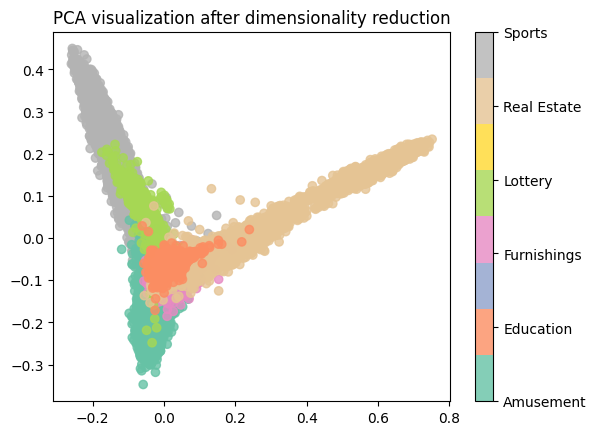

In [5]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

def vis(X):
    types = df['type'].values
    le = LabelEncoder()
    colors = le.fit_transform(types)
    
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    print(X_pca.shape)
    
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.8, c=colors, cmap='Set2')
    cbar = plt.colorbar(scatter, ticks=range(len(le.classes_)))
    cbar.ax.set_yticklabels(le.classes_)
    plt.title("PCA visualization after dimensionality reduction")
    plt.show()

vis(X)

In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, normalized_mutual_info_score

# ============================================
# 1. 用你当前的数据跑 K-means
# ============================================

# 假设你的 X 是向量矩阵 (1200, 1000)
# cluster_range = range(2, 11)  # 测试 K=2 到 K=10

# 存储结果
sse_list = []      # 簇内误差平方和
silhouette_list = []  # 轮廓系数
k_range = range(2, 14)

print("开始测试不同 K 值...")
for k in k_range:
    print(f"正在运行 K={k} ...", end=" ")
    
    # 创建 K-means 模型
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',    # 作业要求的初始化方法
        n_init=10,           # 运行10次取最优
        random_state=42,     # 固定随机种子
        max_iter=300
    )
    
    # 训练
    kmeans.fit(X)
    
    # 记录 SSE（簇内误差平方和）
    sse_list.append(kmeans.inertia_)
    
    # 记录轮廓系数
    sil_score = silhouette_score(X, kmeans.labels_)
    silhouette_list.append(sil_score)
    
    print(f"SSE={kmeans.inertia_:.0f}, Silhouette={sil_score:.4f}")

print("\n所有 K 值测试完成！")


# ============================================
# 2. 查看结果并选最佳 K
# ============================================

print("\n=== 各 K 值结果 ===")
print("K\tSSE\t\t轮廓系数")
print("-" * 40)
for i, k in enumerate(k_range):
    print(f"{k}\t{sse_list[i]:.0f}\t\t{silhouette_list[i]:.4f}")

# 找出轮廓系数最高的 K
best_k = k_range[np.argmax(silhouette_list)]
print(f"\n轮廓系数最高的 K 值: {best_k}")

# 你也可以手动看图确定肘点，这里先用轮廓系数最高的 K


# ============================================
# 3. 用最佳 K 值运行最终聚类
# ============================================

print(f"\n用 K={best_k} 运行最终聚类...")

final_kmeans = KMeans(
    n_clusters=best_k,
    init='k-means++',
    n_init=10,
    random_state=42,
    max_iter=300
)

cluster_labels = final_kmeans.fit_predict(X)  # fit + predict 一步完成

print(f"聚类完成！共 {best_k} 个簇")
print(f"每个簇的文档数量:")
print(pd.Series(cluster_labels).value_counts().sort_index())


开始测试不同 K 值...
正在运行 K=2 ... SSE=39620, Silhouette=0.0283
正在运行 K=3 ... SSE=38738, Silhouette=0.0342
正在运行 K=4 ... SSE=38318, Silhouette=0.0355
正在运行 K=5 ... SSE=37924, Silhouette=0.0309
正在运行 K=6 ... SSE=37596, Silhouette=0.0343
正在运行 K=7 ... SSE=37274, Silhouette=0.0373
正在运行 K=8 ... SSE=36992, Silhouette=0.0405
正在运行 K=9 ... SSE=36814, Silhouette=0.0412
正在运行 K=10 ... SSE=36595, Silhouette=0.0441
正在运行 K=11 ... SSE=36463, Silhouette=0.0409
正在运行 K=12 ... SSE=36251, Silhouette=0.0438
正在运行 K=13 ... SSE=36137, Silhouette=0.0419

所有 K 值测试完成！

=== 各 K 值结果 ===
K	SSE		轮廓系数
----------------------------------------
2	39620		0.0283
3	38738		0.0342
4	38318		0.0355
5	37924		0.0309
6	37596		0.0343
7	37274		0.0373
8	36992		0.0405
9	36814		0.0412
10	36595		0.0441
11	36463		0.0409
12	36251		0.0438
13	36137		0.0419

轮廓系数最高的 K 值: 10

用 K=10 运行最终聚类...
聚类完成！共 10 个簇
每个簇的文档数量:
0     1518
1     1240
2     2880
3     5615
4     2180
5     3342
6     6835
7      690
8     7811
9    10317
Name: count, dtype: int64



=== 评估指标 ===
轮廓系数 (Silhouette Score): 0.0441
NMI (归一化互信息): 0.6732
纯度 (Purity): 0.9205

=== 每个簇的真实类别分布 ===

簇 0 (共 1518 篇文档):
Sports         1517
Real Estate       1
Name: count, dtype: int64

簇 1 (共 1240 篇文档):
Education    1239
Amusement       1
Name: count, dtype: int64

簇 2 (共 2880 篇文档):
Real Estate    2880
Name: count, dtype: int64

簇 3 (共 5615 篇文档):
Furnishings    3834
Real Estate    1655
Education        61
Name: count, dtype: int64

簇 4 (共 2180 篇文档):
Sports    2180
Name: count, dtype: int64

簇 5 (共 3342 篇文档):
Sports       3341
Amusement       1
Name: count, dtype: int64

簇 6 (共 6835 篇文档):
Amusement      6816
Real Estate       9
Lottery           5
Name: count, dtype: int64

簇 7 (共 690 篇文档):
Lottery        689
Real Estate      1
Name: count, dtype: int64

簇 8 (共 7811 篇文档):
Sports       7235
Lottery       563
Amusement       7
Name: count, dtype: int64

簇 9 (共 10317 篇文档):
Amusement    9325
Sports        295
Education     284
Name: count, dtype: int64


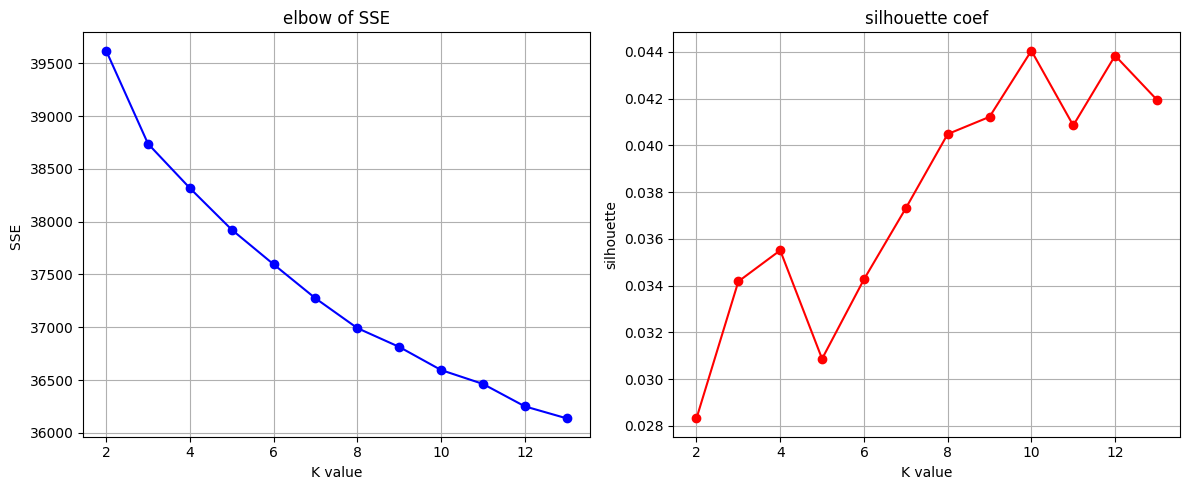

In [7]:
# ============================================
# 4. 计算评估指标
# ============================================

# 真实标签
true_labels = df['type'].tolist()

# 4.1 轮廓系数
sil_score_final = silhouette_score(X, cluster_labels)
print(f"\n=== 评估指标 ===")
print(f"轮廓系数 (Silhouette Score): {sil_score_final:.4f}")

# 4.2 NMI（归一化互信息）
nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
print(f"NMI (归一化互信息): {nmi_score:.4f}")

# 4.3 纯度 (Purity)
# 手动计算
purity = 0
for cluster_id in range(best_k):
    # 找出属于当前簇的所有文档的索引
    mask = (cluster_labels == cluster_id)
    if mask.sum() == 0:
        continue
    # 统计该簇中各类别的数量
    cluster_types = pd.Series(true_labels)[mask]
    max_count = cluster_types.value_counts().max()
    purity += max_count

purity = purity / len(cluster_labels)
print(f"纯度 (Purity): {purity:.4f}")


# ============================================
# 5. 查看每个簇的真实类别分布（理解聚类结果）
# ============================================

print("\n=== 每个簇的真实类别分布 ===")
for cluster_id in range(best_k):
    mask = (cluster_labels == cluster_id)
    cluster_types = pd.Series(true_labels)[mask]
    print(f"\n簇 {cluster_id} (共 {mask.sum()} 篇文档):")
    print(cluster_types.value_counts().head(3))  # 显示前3个最多的类别


# ============================================
# 6. 画出肘部图
# ============================================

plt.figure(figsize=(12, 5))

# 子图1：肘部图（SSE）
plt.subplot(1, 2, 1)
plt.plot(k_range, sse_list, 'bo-')
plt.xlabel('K value')
plt.ylabel('SSE ')
plt.title('elbow of SSE')
plt.grid(True)

# 子图2：轮廓系数图
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_list, 'ro-')
plt.xlabel('K value')
plt.ylabel('silhouette')
plt.title('silhouette coef')
plt.grid(True)

plt.tight_layout()
plt.show()